# Setup - Downloading the data

### <u>Database Collection </u>
Patent data was retrieved from Lens.org to understand the global antibody-drug conjugate (ADC) oncology landscape and competitive field
<br>

### <u>Search Query</u>
Patents: `class_cpc.symbol:(A61P35*) AND (class_cpc.symbol:(C07K16*) OR class_cpc.symbol:(C07K2317*)) AND (class_cpc.symbol:(A61K2039*) OR class_cpc.symbol:(A61K47*)) AND (class_cpc.symbol:(C07D*) OR class_cpc.symbol:(A61K31*)) AND jurisdiction: US`

CPC filters were used for:  
    A) Oncology indiciation (A61P35/*) -> Inventions for cancer treatments  
    B) Immunoglobulins (C07K16/* or C07K2317/*) -> Therapeutic agent is antibody-related  
    C) Chemical conjugation/linker (A61K2039/* or A61K47/*) -> Antibody is chemically linked to another compound (ADC)  
    D) Cytotoxic payload (C07D* or A61K31/*) -> Uses cytotoxic drug as payload  
For the purposes of this case study, jurisdiction was focused on US 
<br>

Filters: `Published Date = (2006-01-01 - 2026-02-24) Expanded by Simple Families Document Type = (Patent_application, Granted_patent) Legal Status = (Pending, Active)`
- Date Range: Filtered by years of 2006 to 2026; want to look at current competitive space with 20 year term blackout window
- Document Type = Patent application and Granted patent
- Legal Status: Active, Pending

Will see that there are 5,783 Patent Records
- With 2,331 Simple Families
- And 2,265 Extended Families

This 2,331 families, which would be all patent records with jurisdiction in the US that are ADC Oncology related, was saved as `US-enforced-patents.jsonl`
- They are Active or Pending 

### <u>Global ADC Oncology Landscape</u>
To look at global oncology landscape, also obtained a file with removal of `jurisdiction: US`
- This will result in 36,656 patent records
- Made of 3,982 Simple Families and 3,849 Extended Families
- Select the 3,982 simple family and file was saved as `Global-ADC-Oncology-Patent-Landscape-01_01_2006-02_24_2026.csv`
- This file will be examined first to get a broad understanding of the global patent space

<br>

> ### Terminology — Patent Families
> All filings/applications for the same _invention_ comprise a patent family.
>  
> **Simple family**  
> From The Lens: "A simple patent family is a group of patent documents that stem from the same initial document, called the priority document."
> - All members share the same priority or combination of priorities  
> - Acts as “equals” of the invention  
> - E.g. identical filings in different countries  
>  
> **Extended family**  
> From The Lens: "An extended family is a collection of patent applications that stem from similar technical content."
> - Any member shares at least one priority with at least one other member  
> - Includes variations, continuations, improvements


<br>

---


# Current ADC Patent Landscape

In [35]:
import pandas as pd

df = pd.read_csv("../data/raw/Global-ADC-Oncology-Patent-Landscape-01_01_2006-02_24_2026.csv")

print(df.shape)
print(df.columns)
print(df[['#', 'Publication Year', 'Applicants', 'Lens ID', 'Simple Family Size','Simple Family Members']].head())

(3983, 37)
Index(['#', 'Jurisdiction', 'Kind', 'Display Key', 'Lens ID',
       'Publication Date', 'Publication Year', 'Application Number',
       'Application Date', 'Priority Numbers', 'Earliest Priority Date',
       'Title', 'Abstract', 'Applicants', 'Inventors', 'Owners', 'URL',
       'Document Type', 'Has Full Text', 'Cites Patent Count',
       'Cited by Patent Count', 'Simple Family Size', 'Simple Family Members',
       'Simple Family Member Jurisdictions', 'Extended Family Size',
       'Extended Family Members', 'Extended Family Member Jurisdictions',
       'Sequence Count', 'CPC Classifications', 'IPCR Classifications',
       'US Classifications', 'NPL Citation Count',
       'NPL Resolved Citation Count', 'NPL Resolved Lens ID(s)',
       'NPL Resolved External ID(s)', 'NPL Citations', 'Legal Status'],
      dtype='object')
   #  Publication Year                                   Applicants  \
0  1              2016                                     第一三共株式会社   
1  2

### <span style="background-color: yellow; color: black;">Question 1 - Is the global ADC market a crowded space?</span>

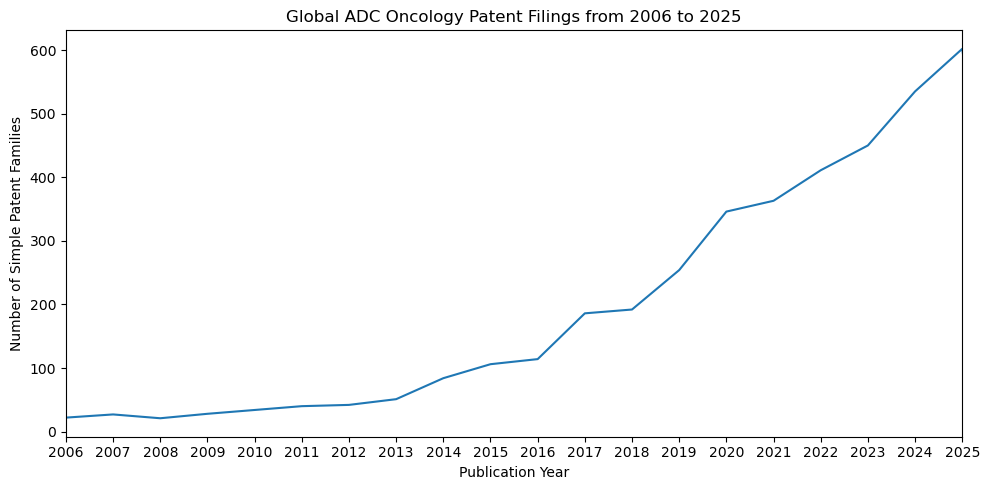

In [36]:
import matplotlib.pyplot as plt

year_counts = df['Publication Year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(year_counts.index, year_counts.values)

plt.xlim(2006, 2025) #2026 excluded due to incomplete year coverage (currently February 24, 2026)
plt.xticks(range(2006, 2026, 1)) 

plt.title("Global ADC Oncology Patent Filings from 2006 to 2025")
plt.xlabel("Publication Year")
plt.ylabel("Number of Simple Patent Families")
plt.tight_layout()
plt.show()

Note that patent applications are published 18 months from earliest priority date. Due to this 18-month publication delay of patent applications, filings from 2025–2026 may be underrepresented in public databases like Lens
- Therefore, the 2024 & 2025 number should be interpreted cautiously.

### <span style="background-color: yellow; color: black;">Question 2 - Who are the large competitors in this space?</span> 

#### **1) VOLUME BASED**

Applicants
GENENTECH INC                  127
NOVARTIS AG                     78
HOFFMANN LA ROCHE               74
DAIICHI SANKYO CO LTD           61
JANSSEN BIOTECH INC             50
UNIV TEXAS                      49
MEDIMMUNE LTD                   39
IMMUNOGEN INC                   38
UNIV CALIFORNIA                 38
PFIZER                          33
BRISTOL MYERS SQUIBB CO         32
DANA FARBER CANCER INST INC     28
MERCK SHARP & DOHME             26
SANOFI SA                       26
INST NAT SANTE RECH MED         26
Name: count, dtype: int64


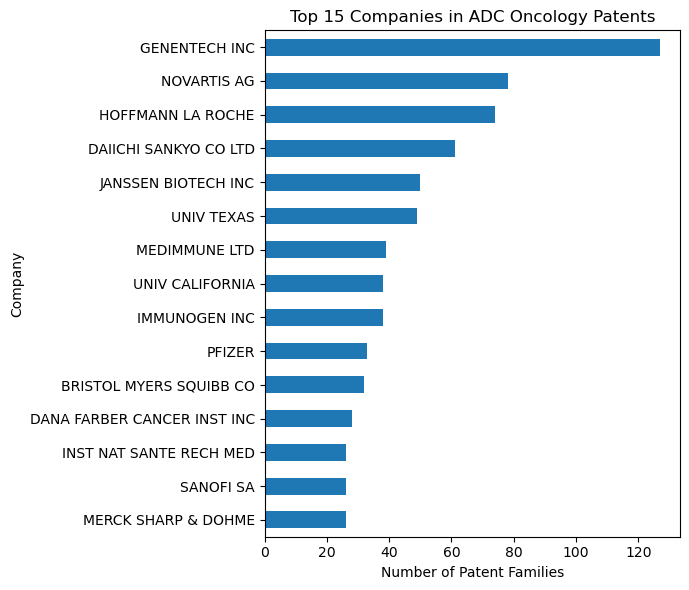

In [37]:
# Split multiple applicants into rows
companies = (
    df['Applicants']
    .dropna() #remove empty applicant cells
    .str.split(';;') #split mutli applicants in a row into a list
    .explode() #each item in list has its own row
    .str.strip() #remove extra spaces
)

companies = companies[companies != ""] #remove any rows with empty cells

top_companies = companies.value_counts().head(15) #occurance of each unique value (company name); top 15
print(top_companies)

# Make a bar chart of the top 15 companies
import matplotlib.pyplot as plt
plt.figure(figsize=(7,6))
top_companies.sort_values().plot(kind='barh')

plt.title("Top 15 Companies in ADC Oncology Patents")
plt.xlabel("Number of Patent Families")
plt.ylabel("Company")
plt.tight_layout()
plt.show()

These graphs look at companies that file the most ADC oncology patents, where we look at how many patent families mention each company.  
But this looks at <u>volume</u>, not significance. It would treat all patents as equal (e.g. one local patent is the same weight as a globally-dominant platform patent)
  
<br>

#### **1) IMPACT-SCORE BASED**
Next, we will look at the columns of `Simple Family Size`, `Cited by Patent Count`, `Simple Family Member Jurisdictions`, and `Legal Status`:  
- **Family size** will take into account platform patents filed everywhere  
- **Citations** will take into account forward citations, patents that came after the current patent that referenced it  
- **Jurisdiction count** will take into account number of jurisdictions (geographical scope) involved in the patent family; look at global protection per invention
- **Legal Status** looks at current enforceability

In [38]:
#Make a dataframe with these additional parameters for further analysis
impact_df = df[['Applicants',
                'Simple Family Size',
                'Cited by Patent Count',
                'Simple Family Member Jurisdictions',
                'Legal Status']].copy()
#Remove rows with blank in Applicant column (if we don't know who owns the patent, we can't analyze further)
impact_df = impact_df.dropna(subset=['Applicants'])
# Split multiple applicants into rows
impact_df['Applicant'] = impact_df['Applicants'].str.split(';;')
impact_df = impact_df.explode('Applicant') #one row per company
#Remove empty applicant rows
impact_df['Applicant'] = impact_df['Applicant'].str.strip() #remove spaces at start and end of names
impact_df['Applicant'] = impact_df['Applicant'].replace('', pd.NA) #replace empty strings with NaN
impact_df = impact_df.dropna(subset=['Applicant']) #delete rows with NaN in Applicant column

In [39]:
#Count jurisdictions using a new column called j_count:
impact_df['j_count'] = (impact_df['Simple Family Member Jurisdictions']
                        .fillna("") #replace NaN with empty string to avoid errors
                        .str.count(";;") + 1 #each ;; (the county seperator) indicates a new jurisdiction, so count them and add 1
                        )

In [40]:
# Turn Legal status into a weight / quantify:
status_map = {
    "ACTIVE": 1.0,   #in force
    "PENDING": 0.5,  #not enforceable
}
impact_df['legal_number'] = impact_df['Legal Status'].map(status_map) #.map(status_map) will replace the text with number based on dict

#Note: In Lens, "ACTIVE" means granted in at least one country, "PENDING" means filed

In [41]:
#Aggregate by company
company_impact = impact_df.groupby('Applicant').agg({ #group all rows with same Applicant and for each, calculate summary statistics for:
    'Simple Family Size': 'sum', #total size of the patent families it owns (global portfolio size)
    'Cited by Patent Count': 'sum', #total number of times its patents have been cited by other patents
    'j_count': 'sum', #total jurisdictions
    'legal_number': 'mean', #average legal "strength" of its patents
    'Applicant': 'count' #number of patents owned (times it appears in a patent)
    }).rename(columns={'Applicant':'Family Count'}) #rename column of counts of Applicant into "Family Count"

In [42]:
# Normalization - turn the different metrics to compare
#Select columns we want to use for impact score and make into smaller table
features = company_impact[['Simple Family Size',
                            'Cited by Patent Count',
                            'j_count',
                            'legal_number',
                            'Family Count']]

# These 4 columns are in different scales, need to normalize so a column with large values doesn't dominate the others.
# Will be done with min-max normalization (smallest value -> 0; largest value -> 1; everything else scaled in between):
norm = (features - features.min()) / (features.max() - features.min())

# For each company, take the average of the normalized metrics; reflects the relative strength of the patents themselves.
company_impact['Impact Score'] = norm.mean(axis=1) #for each company, average the 4 normalized metrics to get an overall impact score

# I had ran above and stopped but noticed that some companies with one family with very high values (eg large family size, or many citations) were found at the top of the list
# This is because min–max normalization amplifies extremes, making 1 unicorn = 100 solid patents
# So I multiplied the normalized score by a portfolio weight:
portfolio_weight = (
    company_impact['Family Count'] /
    company_impact['Family Count'].max()
)

#Makes final impact score:
company_impact['Impact Score'] = norm.mean(axis=1) * portfolio_weight

#Look at top companies ("foundational" patent holders)
company_impact.sort_values("Impact Score", ascending=False).head(15)

,Simple Family Size,Cited by Patent Count,j_count,legal_number,Family Count,Impact Score
Applicant,,,,,,
GENENTECH INC,3325,278,1685,0.641732,127,0.788759
NOVARTIS AG,1426,421,915,0.589744,78,0.339276
HOFFMANN LA ROCHE,1495,209,833,0.635135,74,0.266819
DAIICHI SANKYO CO LTD,1423,108,660,0.622951,61,0.172697
IMMUNOGEN INC,1339,154,563,0.657895,38,0.102420
JANSSEN BIOTECH INC,698,74,437,0.580000,50,0.093957
MEDIMMUNE LTD,723,115,478,0.692308,39,0.089658
UNIV TEXAS,429,43,295,0.602041,49,0.076434
MERCK SHARP & DOHME,399,343,263,0.634615,26,0.063779


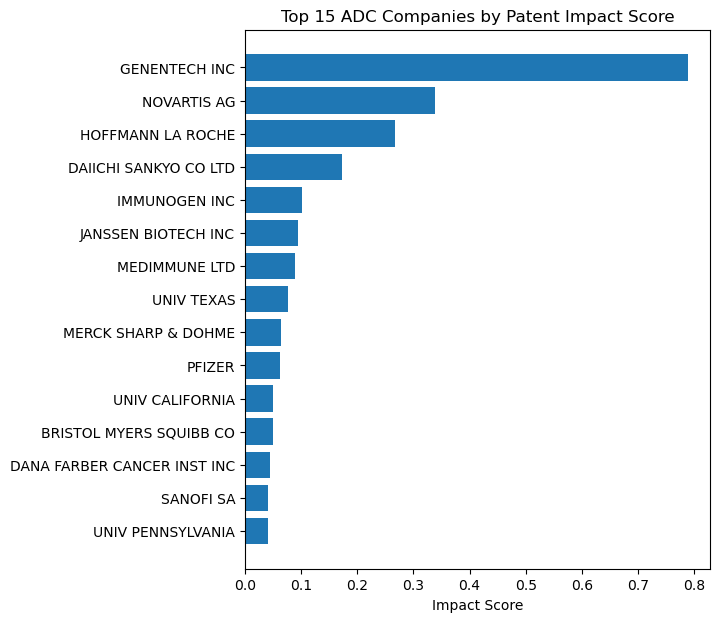

In [43]:
import matplotlib.pyplot as plt

# Get top 15 companies by Impact Score
top_impact = company_impact.sort_values(
    "Impact Score", ascending=False
).head(15)

# Create horizontal bar chart
plt.figure(figsize=(6, 7))
plt.barh(top_impact.index, top_impact["Impact Score"])
plt.xlabel("Impact Score")
plt.title("Top 15 ADC Companies by Patent Impact Score")
plt.gca().invert_yaxis()  # Highest score on top
plt.show()

### <span style="background-color: yellow; color: black;">Question 3 - How many of these Simple Families contain US Jurisdiction?</span> 

Looking at patent families with US protection (based on simple family jurisdictions)

In [45]:
us_df = df[
    df['Simple Family Member Jurisdictions']
    .str.contains('US', na=False)
]

In [46]:
len(us_df)

3216

- Total simple families (global): 3,982
- US-protected families: 3,216

~81% of the global ADC families include US protection
- Makes sense -> For high-value oncology assets, companies almost always file in the US

### <span style="background-color: yellow; color: black;">Question 4 - How does the global expiry horizon look like for all simple patent families?</span> 


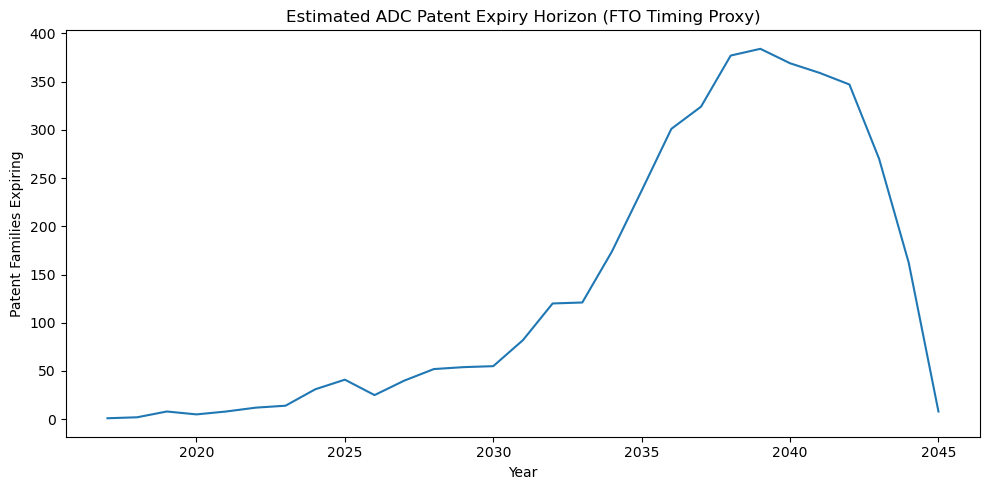

In [48]:
df['Priority Year'] = pd.to_datetime(df['Earliest Priority Date'], errors='coerce').dt.year
df['Expiry Year'] = df['Priority Year'] + 20

expiry = df['Expiry Year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(expiry.index, expiry.values)
plt.title("Estimated ADC Patent Expiry Horizon (FTO Timing Proxy)")
plt.xlabel("Year")
plt.ylabel("Patent Families Expiring")
plt.tight_layout()
plt.show()
